# Module  11 – Dimensionality Reduction

## 1. What is Dimensionality?

Definition: Dimensionality refers to the number of features or columns in a dataset.

Example: A dataset with lead_time, adr, adults, and total_of_special_requests has 4 dimensions.

Why it is used? Understanding dimensionality helps us know how many features are available and whether the dataset may need dimensionality reduction before machine learning.

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    r"C:\Users\HP\Sprint_6_Feature_Engineering_-_Feature_Selection\data\hotel_bookings.csv"
)

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
feature_cols = [
    "lead_time",
    "adults",
    "children",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adr",
    "total_of_special_requests"
]

features = df[feature_cols].fillna(0)

features.shape

(119390, 7)

### Observation

The selected Hotel Booking dataset contains 7 numerical features.

The output of `shape` shows the number of rows and columns in the feature set. The number of columns represents the current dimensionality of the data.

### Code Explanation

- `feature_cols` contains the numerical features selected from the Hotel Bookings dataset.
- `df[feature_cols]` selects these features.
- `fillna(0)` handles missing values.
- `features.shape` returns the number of rows and columns.
- The second value in the output represents the number of dimensions.

## 2. High-Dimensional Data

Definition: High-dimensional data is data that contains a very large number of features, often hundreds or thousands.

Example: Text data with thousands of words, image data with many pixel values, or datasets containing hundreds of numerical columns.

Why it is used? Recognizing high-dimensional data helps us decide whether techniques such as PCA may be useful to reduce the number of features before machine learning.

### Hotel Booking Example

The Hotel Booking dataset used in this notebook contains a smaller number of selected numerical features, so it is not a highly high-dimensional dataset.

However, the same PCA techniques can be demonstrated to understand how dimensionality reduction works.

In [4]:
print("Number of features:", features.shape[1])
print("Number of rows:", features.shape[0])

Number of features: 7
Number of rows: 119390


### Observation

The number of features and rows are displayed separately.

The selected Hotel Booking data has 7 features, so it is not considered highly high-dimensional. PCA is demonstrated here to understand how multiple numerical features can be transformed into fewer dimensions.

### Code Explanation

- `features.shape[1]` returns the number of features.
- `features.shape[0]` returns the number of rows.
- The `print()` statements display both values clearly.

## 3. Curse of Dimensionality

Definition: The Curse of Dimensionality refers to the problems that can occur when the number of features in a dataset becomes very large.

As the number of dimensions increases, data points become more spread out and models may require more data and computational resources to learn useful patterns.

Example: If a dataset has a small number of rows but hundreds or thousands of features, a machine learning model may learn noise instead of meaningful patterns.

Why it is used? Understanding the Curse of Dimensionality explains why reducing unnecessary dimensions can help improve model efficiency and reduce model complexity.

### Hotel Booking Example

The selected Hotel Booking dataset contains only a few numerical features, so it does not strongly demonstrate the Curse of Dimensionality.

We can calculate the ratio of rows to features as a simple check.

In [5]:
ratio = features.shape[0] / features.shape[1]

ratio

17055.714285714286

### Observation

The ratio shows how many observations are available for each feature.

The Hotel Booking dataset has many more rows than the selected features, so the selected dataset does not have a severe dimensionality problem.

### Code Explanation

- `features.shape[0]` returns the number of rows.
- `features.shape[1]` returns the number of features.
- Dividing the number of rows by the number of features gives a simple ratio for understanding the size of the dataset relative to its dimensionality.

## 4. Why Reduce Dimensions?

Definition: Dimensionality Reduction means reducing the number of features in a dataset while keeping most of the important information.

Example: Seven original Hotel Booking features can be transformed into two new features called Principal Components.

Why it is used?

- Reduces the number of features
- Makes data easier to visualize
- Can reduce noise and redundancy
- Can reduce model complexity
- Can improve computational efficiency

### Hotel Booking Example

The selected Hotel Booking features have different scales.

For example:

- `lead_time` can have large numerical values.
- `adr` has a different range.
- `adults` contains much smaller values.

Before applying PCA, the features should be standardized so that one feature does not dominate the result simply because it has a larger numerical scale.

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

pd.DataFrame(
    scaled_features,
    columns=features.columns
).head()

,lead_time,adults,children,stays_in_weekend_nights,stays_in_week_nights,adr,total_of_special_requests
0,2.227051,0.247897,-0.260659,-0.92889,-1.310240,-2.015038,-0.720694
1,5.923385,0.247897,-0.260659,-0.92889,-1.310240,-2.015038,-0.720694
2,-0.907814,-1.478447,-0.260659,-0.92889,-0.786207,-0.530935,-0.720694
3,-0.851667,-1.478447,-0.260659,-0.92889,-0.786207,-0.530935,-0.720694
4,-0.842309,0.247897,-0.260659,-0.92889,-0.262174,-0.075810,0.540666


### Observation

The features have been standardized so that they are on a comparable scale.

This is an important preprocessing step before applying PCA because PCA is affected by the scale of the input features.

### Code Explanation

- `StandardScaler()` creates a standardization object.
- `fit_transform()` calculates the required statistics and transforms the features.
- The transformed features have a mean close to 0 and a standard deviation close to 1.
- `pd.DataFrame()` displays the standardized features in a readable format.

## 5. PCA

Definition: Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms correlated features into a smaller set of new, uncorrelated features called Principal Components.

Example: The 7 selected Hotel Booking features can be transformed into 2 Principal Components while preserving as much variation in the data as possible.

Why it is used? PCA is one of the most common techniques for reducing numerical dimensions while retaining important information from the original features.

### Hotel Booking Example

PCA can transform features such as `lead_time`, `adr`, `adults`, and stay-related features into a smaller number of Principal Components.

Before applying PCA, the features are standardized because PCA is sensitive to feature scale.

In [7]:
from sklearn.decomposition import PCA

pca_full = PCA()

pca_full.fit(scaled_features)

pca_full.explained_variance_ratio_

array([0.24320016, 0.20077914, 0.14871624, 0.13911922, 0.11159454,
       0.0864068 , 0.0701839 ])

### Observation

PCA calculates Principal Components from the standardized Hotel Booking features.

The `explained_variance_ratio_` shows how much of the total variation in the dataset is captured by each Principal Component.

The first Principal Component captures the largest amount of variation, followed by the second, third, and so on.

### Code Explanation

- `PCA()` creates a PCA object without specifying the number of components.
- `fit()` learns the Principal Components from the standardized features.
- `explained_variance_ratio_` returns the proportion of variance explained by each component.
- The components are ordered from the one explaining the most variance to the one explaining the least.

## 6. Principal Components

Definition: Principal Components are new features created by PCA from the original features.

Each Principal Component is a combination of the original features and represents a particular direction of variation in the data.

The first Principal Component (PC1) captures the highest amount of variation.

The second Principal Component (PC2) captures the next highest amount of variation, and so on.

### Hotel Booking Example

The original Hotel Booking features such as `lead_time`, `adr`, `adults`, and stay-related features are combined to create new Principal Components.

These components can represent the important patterns in the original features using fewer dimensions.

In [8]:
pca2 = PCA(n_components=2)

transformed = pca2.fit_transform(scaled_features)

pd.DataFrame(
    transformed,
    columns=["PC1", "PC2"]
).head()

,PC1,PC2
0,-1.772119,-1.365608
1,-1.174627,-2.798974
2,-2.037029,0.177436
3,-2.027954,0.155664
4,-0.624444,0.809237


### Observation

The 7 original Hotel Booking features have been transformed into 2 new features: `PC1` and `PC2`.

These two Principal Components contain information from the original features but represent the data in a lower-dimensional form.

### Code Explanation

- `PCA(n_components=2)` specifies that we want two Principal Components.
- `fit_transform()` learns the components and transforms the standardized data.
- `PC1` represents the direction with the highest variation.
- `PC2` represents the direction with the second-highest variation.
- The resulting data now has only two dimensions instead of the original seven.

## 7. Explained Variance

Definition: Explained Variance shows how much of the total information or variation in the original dataset is captured by each Principal Component.

A higher explained variance means that the Principal Component preserves more information from the original features.

For example:

- PC1 captures the largest amount of variation.
- PC2 captures the next largest amount.
- Later components generally capture less variation.

### Hotel Booking Example

For the Hotel Booking dataset, explained variance helps us decide how many Principal Components should be retained while reducing the original number of features.

In [9]:
explained_variance = pca_full.explained_variance_ratio_

explained_variance

array([0.24320016, 0.20077914, 0.14871624, 0.13911922, 0.11159454,
       0.0864068 , 0.0701839 ])

### Observation

The output shows the proportion of variance explained by each Principal Component.

PC1 explains the highest amount of variation, followed by PC2 and the remaining components.

These values help us understand how much information is retained when reducing the number of features.

### Code Explanation

- `pca_full.explained_variance_ratio_` returns the explained variance ratio for every Principal Component.
- Each value represents the percentage of total variation captured by that component.
- By examining these values, we can decide how many components are sufficient for dimensionality reduction.

## 8. Eigenvectors

Definition: Eigenvectors represent the directions in which the data varies after applying PCA.

In PCA, each Principal Component is based on an eigenvector. The values in an eigenvector show how strongly each original feature contributes to that Principal Component.

### Hotel Booking Example

For the Hotel Booking dataset, the eigenvectors describe how features such as `lead_time`, `adr`, `adults`, and stay-related features contribute to the Principal Components.

The larger the absolute value of a feature's coefficient, the stronger its contribution to that component.

In [10]:
pca_full.components_

array([[ 1.61644522e-01,  3.51229354e-01,  2.82808757e-01,
         5.16718076e-01,  5.31514132e-01,  3.83824537e-01,
         2.71481266e-01],
       [-3.87780354e-01,  1.35538591e-01,  4.38411060e-01,
        -3.58785605e-01, -3.86238370e-01,  5.14649898e-01,
         3.10289741e-01],
       [ 6.24061210e-01,  6.24331345e-01, -1.05485997e-01,
        -3.21546943e-01, -2.21943293e-01,  1.26842299e-01,
        -2.02213879e-01],
       [-2.28354233e-01,  3.51370713e-01, -6.13728710e-01,
         6.30779472e-04, -4.68985713e-02, -1.66287905e-01,
         6.46435222e-01],
       [ 5.80683875e-01, -4.13568878e-01,  2.38206908e-01,
        -1.80614002e-01, -3.72609989e-02, -1.76937513e-01,
         6.08036024e-01],
       [ 1.51375000e-01, -4.09896296e-01, -5.29320155e-01,
        -1.10090565e-01,  1.20396023e-01,  7.07832322e-01,
        -3.53422914e-02],
       [-1.47618571e-01,  7.72142159e-02,  5.56988960e-02,
        -6.75382214e-01,  7.07792882e-01, -1.08351699e-01,
        -1.7098717

### Observation

The output shows the eigenvectors of the PCA model.

Each row represents one Principal Component, and each value represents the contribution of an original Hotel Booking feature to that component.

### Code Explanation

- `pca_full.components_` returns the component vectors learned by PCA.
- Each row corresponds to one Principal Component.
- Each column corresponds to an original feature.
- The values indicate the direction and relative contribution of each feature.
- Positive and negative values indicate the direction of the feature's contribution.

## 9. Eigenvalues

Definition: Eigenvalues represent the amount of variance captured along the directions represented by the eigenvectors.

In PCA, larger eigenvalues indicate Principal Components that capture more variation in the data.

The Principal Components are arranged in descending order of their eigenvalues.

### Hotel Booking Example

For the Hotel Booking dataset, the eigenvalues help identify which Principal Components contain the most variation from the original features.

PC1 generally has the largest eigenvalue because it captures the highest amount of variance.

In [11]:
pca_full.explained_variance_

array([1.70241539, 1.40546575, 1.04102238, 0.97384268, 0.78116835,
       0.60485264, 0.49129145])

### Observation

The output shows the eigenvalues calculated by PCA for the Hotel Booking features.

The first value is the largest, meaning the first Principal Component captures the greatest amount of variance.

### Code Explanation

- `pca_full.explained_variance_` returns the eigenvalues for all Principal Components.
- Each value represents the variance captured by its corresponding component.
- Larger eigenvalues indicate more important components in terms of variance.
- These values are used along with explained variance ratio to understand how much information each component retains.

## 10. PCA Transformation

PCA Transformation converts the original standardized features into Principal Components.

The transformed dataset has fewer dimensions while preserving as much variation from the original data as possible.

### Hotel Booking Example

The original Hotel Booking dataset contains 7 selected numerical features.

Using PCA, these features can be transformed into 2 Principal Components:

- PC1
- PC2

This makes the dataset easier to work with and can also help with visualization.

In [12]:
pca2 = PCA(n_components=2)

transformed = pca2.fit_transform(scaled_features)

transformed_df = pd.DataFrame(
    transformed,
    columns=["PC1", "PC2"]
)

transformed_df.head()

,PC1,PC2
0,-1.772119,-1.365608
1,-1.174627,-2.798974
2,-2.037029,0.177436
3,-2.027954,0.155664
4,-0.624444,0.809237


### Observation

The original 7 numerical features have been transformed into 2 Principal Components.

The resulting dataset contains only `PC1` and `PC2`, while retaining the main patterns and variation from the original features.

### Code Explanation

- `PCA(n_components=2)` creates a PCA model with two components.
- `fit_transform()` learns the PCA transformation and applies it to the standardized data.
- `transformed_df` stores the transformed values.
- `PC1` and `PC2` are the new reduced features.

## 11. PCA Visualization

PCA can be used to visualize high-dimensional data by reducing it to 2 or 3 Principal Components.

A 2D scatter plot can show the relationship between PC1 and PC2.

### Hotel Booking Example

The Hotel Booking features are reduced to two Principal Components, `PC1` and `PC2`.

Plotting these two components helps us visually understand the overall distribution and patterns in the dataset.

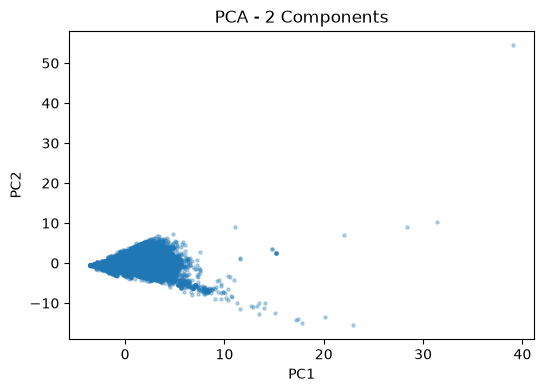

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

plt.scatter(
    transformed_df["PC1"],
    transformed_df["PC2"],
    alpha=0.3,
    s=5
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - 2 Components")

plt.show()

### Observation

The scatter plot represents the Hotel Booking data using only two dimensions: PC1 and PC2.

Each point represents a booking record. The plot helps us observe the overall distribution and possible patterns in the reduced dataset.

### Code Explanation

- `plt.figure()` creates the figure.
- `plt.scatter()` plots PC1 against PC2.
- `alpha=0.3` makes overlapping points easier to see.
- `s=5` keeps the points small because the dataset contains many booking records.
- `plt.xlabel()` and `plt.ylabel()` label the Principal Components.
- `plt.show()` displays the visualization.

## 12. Advantages of PCA

PCA provides several benefits when working with datasets that contain many numerical features.

### Advantages

- Reduces the number of features while preserving important information.
- Helps reduce correlation between features.
- Can make model training faster.
- Reduces memory usage when fewer features are used.
- Makes high-dimensional data easier to visualize in 2D or 3D.
- Can help reduce noise and redundancy in the dataset.

### Hotel Booking Example

PCA can reduce several Hotel Booking features into a smaller number of Principal Components.

This can make the data easier to analyze and visualize while retaining the major patterns present in the original features.

In [14]:
print("Original number of features:", features.shape[1])
print("Reduced number of features:", transformed_df.shape[1])

print(
    "Variance retained by 2 components:",
    pca2.explained_variance_ratio_.sum()
)

Original number of features: 7
Reduced number of features: 2
Variance retained by 2 components: 0.44397930152701637


### Observation

The original Hotel Booking features have been reduced to two Principal Components.

The variance retained value shows how much of the original variation is preserved by these two components.

### Code Explanation

- `features.shape[1]` gives the number of original features.
- `transformed_df.shape[1]` gives the number of reduced features.
- `pca2.explained_variance_ratio_.sum()` calculates the total variance explained by PC1 and PC2.
- PCA can therefore reduce dimensionality while retaining a significant amount of information.

## 13. Limitations of PCA

Although PCA is useful for dimensionality reduction, it also has some limitations.

### Limitations

- Principal Components may be difficult to interpret because they are combinations of original features.
- PCA mainly captures linear relationships.
- PCA is sensitive to feature scaling.
- Important information may be lost if too few components are selected.
- PCA works mainly with numerical features and is not directly suitable for categorical features.

### Hotel Booking Example

For the Hotel Booking dataset, reducing 7 features to only 2 Principal Components may cause some information to be lost.

Also, `PC1` and `PC2` do not directly represent a single business feature such as `lead_time` or `adr`, which makes them less interpretable.

In [15]:
print("Original features:")
print(list(features.columns))

print("\nPCA components:")
print(["PC1", "PC2"])

print(
    "\nVariance retained by 2 components:",
    pca2.explained_variance_ratio_.sum()
)

Original features:
['lead_time', 'adults', 'children', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adr', 'total_of_special_requests']

PCA components:
['PC1', 'PC2']

Variance retained by 2 components: 0.44397930152701637


### Observation

The PCA transformation reduces the original features to two components, but the new components do not have the same direct business meaning as the original features.

The variance retained value also helps identify how much information is preserved after dimensionality reduction.

### Code Explanation

- The original feature names are displayed for comparison.
- `PC1` and `PC2` represent combinations of the original features.
- `explained_variance_ratio_.sum()` shows the total variation retained by the two components.
- Therefore, PCA should be applied carefully when feature interpretability is important.

## 14. When to Use PCA

PCA is useful when a dataset contains many numerical features and dimensionality needs to be reduced.

### When to Use PCA?

- When the dataset has many numerical features.
- When several features are highly correlated.
- When model training becomes slower because of a large number of features.
- When multicollinearity is present.
- When high-dimensional data needs to be visualized in 2D or 3D.
- When reducing noise and redundant information is useful.

### Hotel Booking Example

PCA can be considered for Hotel Booking data when many numerical and engineered features are created and some of them are correlated.

It can reduce these features into a smaller set of Principal Components for analysis or machine learning.

In [16]:
print("Number of original features:", features.shape[1])
print("Number of PCA components:", transformed_df.shape[1])

print(
    "Variance retained:",
    pca2.explained_variance_ratio_.sum()
)

Number of original features: 7
Number of PCA components: 2
Variance retained: 0.44397930152701637


### Observation

PCA reduced the selected Hotel Booking features from 7 dimensions to 2 dimensions.

The variance retained value indicates how much of the original information is represented by these two components.

### Code Explanation

- `features.shape[1]` shows the original number of features.
- `transformed_df.shape[1]` shows the number of PCA components.
- `explained_variance_ratio_.sum()` shows the total variance retained.
- This demonstrates how PCA can reduce dimensions while preserving important patterns in the data.

## 15. When Not to Use PCA

PCA is not always the best choice for every dataset or machine learning problem.

### When Not to Use PCA?

- When the number of features is already small.
- When feature interpretability is very important.
- When the dataset contains mostly categorical features.
- When preserving the original feature meaning is required.
- When the relationships between features are strongly nonlinear.
- When reducing dimensions may remove important information.

### Hotel Booking Example

The Hotel Booking dataset has a manageable number of selected numerical features.

Therefore, PCA may not always be necessary for the original features.

However, PCA can become useful if many additional numerical features are created during feature engineering.

In [17]:
print("Original number of features:", features.shape[1])

if features.shape[1] <= 10:
    print("PCA may not be necessary for this small feature set.")
else:
    print("PCA may be useful for reducing dimensionality.")

Original number of features: 7
PCA may not be necessary for this small feature set.


### Observation

The current Hotel Booking example uses only 7 numerical features.

Since the number of features is relatively small, dimensionality reduction may not be necessary for a basic machine learning model.

PCA becomes more useful when the number of numerical features becomes large or when strong correlation and redundancy are present.

### Code Explanation

- `features.shape[1]` returns the number of selected features.
- The `if` condition checks whether the number of features is small.
- The message helps determine whether PCA may be useful based on the current feature count.
- This is a simple demonstration; the final decision should also consider correlation, model performance, interpretability, and information loss.